In [14]:
# Cell 0 — Project Imports

import matplotlib.pyplot as plt
import numpy as np
import torch

In [15]:
# Cell 1 — CT Hounsfield Unit와 Tissue Reference

def convert_stored_values_to_hu(
    stored_values: torch.Tensor,  # [N] 또는 [D, H, W]
    rescale_slope: float,
    rescale_intercept: float,
) -> torch.Tensor:                # 입력과 동일 Shape
    """DICOM stored value를 rescale parameter로 HU 변환."""
    
    # DICOM modality rescale 공식 적용
    #
    # HU = Stored Value × Rescale Slope
    #      + Rescale Intercept
    hu_values = (
        stored_values.to(dtype=torch.float32)
        * rescale_slope
        + rescale_intercept
    )
    
    return hu_values


stored_values = torch.tensor(
    [
        0,
        24,
        924,
        1024,
        1064,
        1124,
        2024,
    ],
    dtype=torch.int16,
)  # [N=7]

# 각 reference voxel의 의미
reference_names: tuple[str, ...] = (
    "Outside scanner range",
    "Air",
    "Fat reference",
    "Water",
    "Soft-tissue reference",
    "Enhanced-tissue reference",
    "Dense-bone reference",
)

# 가상 DICOM metadata의 rescale parameter
rescale_slope: float = 1.0
rescale_intercept: float = -1024.0


# Stored Value를 HU로 변환
hu_values = convert_stored_values_to_hu(
    stored_values=stored_values,
    rescale_slope=rescale_slope,
    rescale_intercept=rescale_intercept,
)  # [N=7], torch.float32


print(
    "Stored dtype:",
    stored_values.dtype,
)

print(
    "HU dtype:",
    hu_values.dtype,
)

print(
    "Rescale slope:",
    rescale_slope,
)

print(
    "Rescale intercept:",
    rescale_intercept,
)

print()

# 각 reference의 stored value와 변환된 HU 출력
for (
    reference_name,
    stored_value,
    hu_value,
) in zip(
    reference_names,
    stored_values,
    hu_values,
    strict=True,
):
    print(
        f"{reference_name:27s} | "
        f"stored={stored_value.item():4d} | "
        f"HU={hu_value.item():7.1f}"
    )

Stored dtype: torch.int16
HU dtype: torch.float32
Rescale slope: 1.0
Rescale intercept: -1024.0

Outside scanner range       | stored=   0 | HU=-1024.0
Air                         | stored=  24 | HU=-1000.0
Fat reference               | stored= 924 | HU= -100.0
Water                       | stored=1024 | HU=    0.0
Soft-tissue reference       | stored=1064 | HU=   40.0
Enhanced-tissue reference   | stored=1124 | HU=  100.0
Dense-bone reference        | stored=2024 | HU= 1000.0


In [16]:
# Cell 2 — CT Windowing과 Unit-Range Normalization

def apply_ct_window(
    ct_hu: torch.Tensor,  # 임의 Shape, torch.float 계열
    window_center_hu: float,
    window_width_hu: float,
) -> tuple[
    torch.Tensor,  # Windowed HU, 입력과 동일 Shape
    torch.Tensor,  # Normalized value [0, 1], 입력과 동일 Shape
]:
    """CT HU를 지정한 window로 clipping하고 [0, 1] 범위로 변환."""
    
    # 양수가 아닌 window width 차단
    if window_width_hu <= 0:
        raise ValueError(
            "window_width_hu는 0보다 커야 합니다."
        )

    # Window의 HU 하한 계산
    lower_bound_hu = (
        window_center_hu
        - window_width_hu / 2
    )

    # Window의 HU 상한 계산
    upper_bound_hu = (
        window_center_hu
        + window_width_hu / 2
    )
    
    # 계산 가능한 floating-point HU Tensor로 변환
    ct_hu_float = ct_hu.to(
        dtype=torch.float32
    )

    # Window 범위 밖의 HU를 하한 또는 상한으로 clipping
    windowed_ct_hu = torch.clamp(
        ct_hu_float,
        min=lower_bound_hu,
        max=upper_bound_hu,
    )  # 입력과 동일 Shape
    
    # [lower, upper] HU 범위를 [0, 1]로 선형 변환
    normalized_ct = (
        windowed_ct_hu
        - lower_bound_hu
    ) / (
        upper_bound_hu
        - lower_bound_hu
    )  # 입력과 동일 Shape

    return (
        windowed_ct_hu,
        normalized_ct,
    )
    
# Windowing 동작을 확인할 HU reference 생성
ct_reference_hu = torch.tensor(
    [
        -1024.0,
        -160.0,
        -100.0,
        0.0,
        40.0,
        100.0,
        240.0,
        1000.0,
    ],
    dtype=torch.float32,
)  # [N=8]


# 넓은 abdominal soft-tissue window 설정
#
# Center = 40 HU
# Width  = 400 HU
#
# Lower = -160 HU
# Upper =  240 HU
window_center_hu: float = 40.0
window_width_hu: float = 400.0


# HU clipping과 [0, 1] normalization 적용
(
    windowed_reference_hu,
    normalized_reference,
) = apply_ct_window(
    ct_hu=ct_reference_hu,
    window_center_hu=window_center_hu,
    window_width_hu=window_width_hu,
)  # 각 Tensor Shape: [N=8]


# Window의 실제 HU 경계 계산
lower_bound_hu = (
    window_center_hu
    - window_width_hu / 2
)

upper_bound_hu = (
    window_center_hu
    + window_width_hu / 2
)


print(
    "Window center:",
    window_center_hu,
    "HU",
)

print(
    "Window width:",
    window_width_hu,
    "HU",
)

print(
    "Window range:",
    (
        lower_bound_hu,
        upper_bound_hu,
    ),
    "HU",
)

print()

# 각 HU가 clipping과 normalization을 거쳐
# 어떤 값으로 변환되는지 출력
for (
    original_hu,
    windowed_hu,
    normalized_value,
) in zip(
    ct_reference_hu,
    windowed_reference_hu,
    normalized_reference,
    strict=True,
):
    print(
        f"Original={original_hu.item():8.1f} HU | "
        f"Windowed={windowed_hu.item():7.1f} HU | "
        f"Normalized={normalized_value.item():.3f}"
    )

Window center: 40.0 HU
Window width: 400.0 HU
Window range: (-160.0, 240.0) HU

Original= -1024.0 HU | Windowed= -160.0 HU | Normalized=0.000
Original=  -160.0 HU | Windowed= -160.0 HU | Normalized=0.000
Original=  -100.0 HU | Windowed= -100.0 HU | Normalized=0.150
Original=     0.0 HU | Windowed=    0.0 HU | Normalized=0.400
Original=    40.0 HU | Windowed=   40.0 HU | Normalized=0.500
Original=   100.0 HU | Windowed=  100.0 HU | Normalized=0.650
Original=   240.0 HU | Windowed=  240.0 HU | Normalized=1.000
Original=  1000.0 HU | Windowed=  240.0 HU | Normalized=1.000


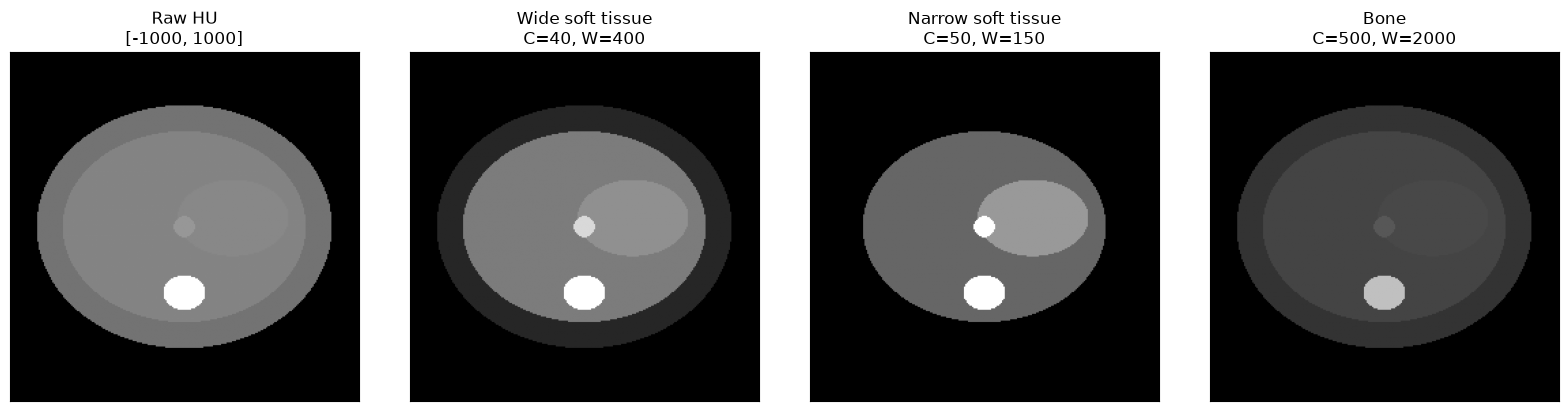

Raw CT shape: torch.Size([256, 256])
Multi-window input shape: torch.Size([3, 256, 256])
Wide-window range: (0.0, 1.0)
Narrow-window range: (0.0, 1.0)
Bone-window range: (0.0, 0.75)


In [17]:
# Cell 3 — 서로 다른 CT Window의 조직 대비 비교

# Synthetic axial CT를 만들기 위한 2D 좌표 생성
height_coordinates = torch.linspace(
    -1.0,
    1.0,
    steps=256,
)  # [H=256]

width_coordinates = torch.linspace(
    -1.0,
    1.0,
    steps=256,
)  # [W=256]


# Height와 Width 좌표를 2D grid로 확장
grid_h, grid_w = torch.meshgrid(
    height_coordinates,
    width_coordinates,
    indexing="ij",
)  # 각 Tensor Shape: [H=256, W=256]


# 모든 pixel이 공기인 axial CT slice 생성
synthetic_axial_ct_hw = torch.full(
    (
        256,
        256,
    ),
    fill_value=-1000.0,
    dtype=torch.float32,
)  # [H=256, W=256]


# 타원 형태의 body 외곽 영역 생성
body_mask_hw = (
    (grid_w / 0.85).square()
    + (grid_h / 0.70).square()
    <= 1.0
)  # [H, W], torch.bool


# Body 외곽의 지방 영역을 약 -100 HU로 설정
synthetic_axial_ct_hw[
    body_mask_hw
] = -100.0


# Body 내부의 연조직 영역 생성
inner_soft_tissue_mask_hw = (
    (grid_w / 0.70).square()
    + (grid_h / 0.55).square()
    <= 1.0
)  # [H, W], torch.bool


# 내부 연조직을 약 35 HU로 설정
synthetic_axial_ct_hw[
    inner_soft_tissue_mask_hw
] = 35.0


# Liver-like soft-tissue ROI 생성
#
# 실제 장기 segmentation이 아니라
# window contrast 확인을 위한 synthetic 영역
liver_like_mask_hw = (
    ((grid_w - 0.28) / 0.32).square()
    + ((grid_h - 0.05) / 0.22).square()
    <= 1.0
)  # [H, W], torch.bool


# Liver-like ROI를 약 65 HU로 설정
synthetic_axial_ct_hw[
    liver_like_mask_hw
] = 65.0


# Contrast-enhanced vessel-like 영역 생성
vessel_like_mask_hw = (
    grid_w.square()
    + grid_h.square()
    <= 0.06**2
)  # [H, W], torch.bool


# Vessel-like ROI를 약 180 HU로 설정
synthetic_axial_ct_hw[
    vessel_like_mask_hw
] = 180.0


# Posterior 위치에 bone-like 영역 생성
bone_like_mask_hw = (
    (grid_w / 0.12).square()
    + ((grid_h + 0.38) / 0.10).square()
    <= 1.0
)  # [H, W], torch.bool


# Bone-like ROI를 약 1000 HU로 설정
synthetic_axial_ct_hw[
    bone_like_mask_hw
] = 1000.0


# 넓은 abdominal soft-tissue window 적용
(
    _,
    wide_window_hw,
) = apply_ct_window(
    ct_hu=synthetic_axial_ct_hw,
    window_center_hu=40.0,
    window_width_hu=400.0,
)  # [H=256, W=256]


# 좁은 soft-tissue window 적용
(
    _,
    narrow_window_hw,
) = apply_ct_window(
    ct_hu=synthetic_axial_ct_hw,
    window_center_hu=50.0,
    window_width_hu=150.0,
)  # [H=256, W=256]


# Bone window 적용
(
    _,
    bone_window_hw,
) = apply_ct_window(
    ct_hu=synthetic_axial_ct_hw,
    window_center_hu=500.0,
    window_width_hu=2000.0,
)  # [H=256, W=256]


# 세 window를 model input의 Channel axis로 결합
multi_window_chw = torch.stack(
    (
        wide_window_hw,
        narrow_window_hw,
        bone_window_hw,
    ),
    dim=0,
)  # [C=3, H=256, W=256]


# 원본 HU와 세 window를 비교할 subplot 생성
figure, axes = plt.subplots(
    nrows=1,
    ncols=4,
    figsize=(16, 4),
    constrained_layout=True,
)


# 원본 HU 표시
axes[0].imshow(
    synthetic_axial_ct_hw.numpy(),
    cmap="gray",
    vmin=-1000,
    vmax=1000,
    origin="lower",
)

axes[0].set_title(
    "Raw HU\n[-1000, 1000]"
)


# Wide soft-tissue window 표시
axes[1].imshow(
    wide_window_hw.numpy(),
    cmap="gray",
    vmin=0,
    vmax=1,
    origin="lower",
)

axes[1].set_title(
    "Wide soft tissue\nC=40, W=400"
)


# Narrow soft-tissue window 표시
axes[2].imshow(
    narrow_window_hw.numpy(),
    cmap="gray",
    vmin=0,
    vmax=1,
    origin="lower",
)

axes[2].set_title(
    "Narrow soft tissue\nC=50, W=150"
)


# Bone window 표시
axes[3].imshow(
    bone_window_hw.numpy(),
    cmap="gray",
    vmin=0,
    vmax=1,
    origin="lower",
)

axes[3].set_title(
    "Bone\nC=500, W=2000"
)


# 좌표 눈금 제거
for axis in axes:
    axis.set_xticks([])
    axis.set_yticks([])


plt.show()


print(
    "Raw CT shape:",
    synthetic_axial_ct_hw.shape,
)

print(
    "Multi-window input shape:",
    multi_window_chw.shape,
)

print(
    "Wide-window range:",
    (
        wide_window_hw.min().item(),
        wide_window_hw.max().item(),
    ),
)

print(
    "Narrow-window range:",
    (
        narrow_window_hw.min().item(),
        narrow_window_hw.max().item(),
    ),
)

print(
    "Bone-window range:",
    (
        bone_window_hw.min().item(),
        bone_window_hw.max().item(),
    ),
)

In [18]:
# Cell 4 — RAS Physical Coordinate로 Organ Laterality 판정

def infer_laterality_from_ras_x(
    physical_coordinate_xyz_mm: torch.Tensor,  # [3] = [X, Y, Z] mm
    patient_midline_x_mm: float,
    midline_tolerance_mm: float,
) -> str:
    """RAS X coordinate와 patient midline으로 laterality 판정."""

    # Physical coordinate에서 Left/Right를 나타내는 X 추출
    physical_x_mm = float(
        physical_coordinate_xyz_mm[0].item()
    )

    # Patient midline에 대한 signed X distance 계산
    #
    # 음수 → midline보다 Left
    # 양수 → midline보다 Right
    signed_distance_from_midline_mm = (
        physical_x_mm
        - patient_midline_x_mm
    )

    # 허용 범위보다 충분히 음수이면 Left 판정
    if (
        signed_distance_from_midline_mm
        < -midline_tolerance_mm
    ):
        return "Left"

    # 허용 범위보다 충분히 양수이면 Right 판정
    if (
        signed_distance_from_midline_mm
        > midline_tolerance_mm
    ):
        return "Right"

    # Midline 주변 tolerance 안에 있으면 Midline 판정
    return "Midline"


# Synthetic abdominal organ centroid 이름
organ_names: tuple[str, ...] = (
    "Liver",
    "Spleen",
    "Right kidney",
    "Left kidney",
    "Pancreas",
    "Aorta",
    "Inferior vena cava",
)


# 각 장기의 synthetic RAS physical centroid 정의:
# 각 row: [X, Y, Z] mm
# X 음수 → 환자 Left
# X 양수 → 환자 Right
organ_centroids_xyz_mm = torch.tensor(
    [
        [80.0, 20.0, 30.0],    # Liver
        [-80.0, 10.0, 40.0],   # Spleen
        [55.0, -20.0, -10.0],  # Right kidney
        [-55.0, -20.0, -10.0], # Left kidney
        [0.0, 15.0, 10.0],     # Pancreas
        [-10.0, -20.0, 0.0],   # Aorta
        [15.0, -20.0, 0.0],    # Inferior vena cava
    ],
    dtype=torch.float64,
)  # [N=7, XYZ=3]


# Synthetic patient midline 정의
patient_midline_x_mm: float = 0.0


# Midline 판정을 위한 tolerance 정의
#
# X coordinate가 -5~+5 mm이면 Midline으로 분류
midline_tolerance_mm: float = 5.0


# 각 organ centroid의 laterality 판정
organ_lateralities: list[str] = []

for organ_centroid_xyz_mm in organ_centroids_xyz_mm:
    laterality = infer_laterality_from_ras_x(
        physical_coordinate_xyz_mm=(
            organ_centroid_xyz_mm
        ),  # [3]
        patient_midline_x_mm=(
            patient_midline_x_mm
        ),
        midline_tolerance_mm=(
            midline_tolerance_mm
        ),
    )

    organ_lateralities.append(
        laterality
    )


# Organ name, physical centroid와 laterality 출력
for (
    organ_name,
    organ_centroid_xyz_mm,
    organ_laterality,
) in zip(
    organ_names,
    organ_centroids_xyz_mm,
    organ_lateralities,
    strict=True,
):
    print(
        f"{organ_name:20s} | "
        f"centroid XYZ="
        f"{organ_centroid_xyz_mm.tolist()} | "
        f"{organ_laterality}"
    )

Liver                | centroid XYZ=[80.0, 20.0, 30.0] | Right
Spleen               | centroid XYZ=[-80.0, 10.0, 40.0] | Left
Right kidney         | centroid XYZ=[55.0, -20.0, -10.0] | Right
Left kidney          | centroid XYZ=[-55.0, -20.0, -10.0] | Left
Pancreas             | centroid XYZ=[0.0, 15.0, 10.0] | Midline
Aorta                | centroid XYZ=[-10.0, -20.0, 0.0] | Left
Inferior vena cava   | centroid XYZ=[15.0, -20.0, 0.0] | Right


In [19]:
# Cell 5 — CT와 Segmentation Training-Case Audit

def audit_training_case(
    case_id: str,
    ct_volume_dhw: torch.Tensor,              # [D, H, W], floating point
    segmentation_target_dhw: torch.Tensor,    # [D, H, W], torch.long
    spacing_dhw_mm: tuple[float, float, float],
    expected_foreground_class_ids: tuple[int, ...],
) -> dict[str, object]:
    """CT와 segmentation label의 training suitability 항목 조사."""

    # CT와 label의 spatial Shape 일치 여부 확인
    shape_matches = (
        ct_volume_dhw.shape
        == segmentation_target_dhw.shape
    )

    # CT에서 finite value 위치 확인
    #
    # finite:
    # NaN도 아니고 positive/negative Inf도 아닌 값
    finite_ct_mask = torch.isfinite(
        ct_volume_dhw
    )  # [D, H, W], torch.bool

    all_ct_values_are_finite = bool(
        finite_ct_mask.all().item()
    )

    # NaN과 Inf를 제외한 CT 값만 추출
    finite_ct_values = ct_volume_dhw[
        finite_ct_mask
    ]

    # 유효한 CT intensity의 최솟값과 최댓값 계산
    if finite_ct_values.numel() > 0:
        ct_intensity_range_hu: (
            tuple[float, float] | None
        ) = (
            finite_ct_values.min().item(),
            finite_ct_values.max().item(),
        )
    else:
        ct_intensity_range_hu = None

    # Label에 실제로 존재하는 모든 class ID 추출
    all_present_class_ids = tuple(
        int(class_id)
        for class_id in torch.unique(
            segmentation_target_dhw
        ).tolist()
    )

    # Background 0을 제외한 foreground class ID 추출
    present_foreground_class_ids = tuple(
        class_id
        for class_id in all_present_class_ids
        if class_id != 0
    )

    # 예상했지만 현재 case에 없는 class 확인
    missing_foreground_class_ids = tuple(
        sorted(
            set(expected_foreground_class_ids)
            - set(present_foreground_class_ids)
        )
    )

    # Dataset contract에 정의되지 않은 class 확인
    unexpected_foreground_class_ids = tuple(
        sorted(
            set(present_foreground_class_ids)
            - set(expected_foreground_class_ids)
        )
    )

    # 각 foreground class의 voxel 수 계산
    foreground_voxel_counts = {
        class_id: int(
            (
                segmentation_target_dhw
                == class_id
            ).sum().item()
        )
        for class_id in present_foreground_class_ids
    }

    # Volume의 여섯 boundary face를 나타내는 mask 생성
    boundary_mask_dhw = torch.zeros_like(
        segmentation_target_dhw,
        dtype=torch.bool,
    )  # [D, H, W]

    # D축의 첫 번째와 마지막 plane 선택
    boundary_mask_dhw[0, :, :] = True
    boundary_mask_dhw[-1, :, :] = True

    # H축의 첫 번째와 마지막 plane 선택
    boundary_mask_dhw[:, 0, :] = True
    boundary_mask_dhw[:, -1, :] = True

    # W축의 첫 번째와 마지막 plane 선택
    boundary_mask_dhw[:, :, 0] = True
    boundary_mask_dhw[:, :, -1] = True

    # Volume boundary에 존재하는 class ID 추출
    boundary_class_ids = tuple(
        sorted(
            int(class_id)
            for class_id in torch.unique(
                segmentation_target_dhw[
                    boundary_mask_dhw
                ]
            ).tolist()
            if int(class_id) != 0
        )
    )

    # Shape와 spacing으로 approximate physical size 계산
    physical_size_dhw_mm = tuple(
        float(axis_size * axis_spacing)
        for (
            axis_size,
            axis_spacing,
        ) in zip(
            ct_volume_dhw.shape,
            spacing_dhw_mm,
            strict=True,
        )
    )

    # 전체 voxel 중 foreground voxel 비율 계산
    foreground_fraction = float(
        (
            segmentation_target_dhw != 0
        )
        .to(dtype=torch.float32)
        .mean()
        .item()
    )

    # Case별 audit 결과 구성
    audit_report: dict[str, object] = {
        "case_id": case_id,
        "ct_shape": tuple(ct_volume_dhw.shape),
        "target_shape": tuple(
            segmentation_target_dhw.shape
        ),
        "shape_matches": shape_matches,
        "spacing_dhw_mm": spacing_dhw_mm,
        "physical_size_dhw_mm": physical_size_dhw_mm,
        "ct_dtype": str(ct_volume_dhw.dtype),
        "target_dtype": str(
            segmentation_target_dhw.dtype
        ),
        "all_ct_values_are_finite": (
            all_ct_values_are_finite
        ),
        "ct_intensity_range_hu": (
            ct_intensity_range_hu
        ),
        "present_foreground_classes": (
            present_foreground_class_ids
        ),
        "missing_foreground_classes": (
            missing_foreground_class_ids
        ),
        "unexpected_foreground_classes": (
            unexpected_foreground_class_ids
        ),
        "foreground_voxel_counts": (
            foreground_voxel_counts
        ),
        "boundary_touching_classes": (
            boundary_class_ids
        ),
        "foreground_fraction": (
            foreground_fraction
        ),
    }

    return audit_report


# ------------------------------------------------------------
# Case A: 중앙에 모든 예상 class가 존재하는 정상 예제
# ------------------------------------------------------------

case_a_ct_dhw = torch.full(
    (
        16,
        24,
        24,
    ),
    fill_value=-1000.0,
    dtype=torch.float32,
)  # [D=16, H=24, W=24]

# Body-like 영역에 soft-tissue HU 할당
case_a_ct_dhw[
    2:14,
    3:21,
    3:21,
] = 40.0

case_a_target_dhw = torch.zeros(
    (
        16,
        24,
        24,
    ),
    dtype=torch.long,
)  # [D=16, H=24, W=24]

# 중앙 class 1 영역
case_a_target_dhw[
    4:12,
    6:18,
    6:18,
] = 1

# 중앙 class 2 영역
case_a_target_dhw[
    6:10,
    4:8,
    10:14,
] = 2


# ------------------------------------------------------------
# Case B: Class 2가 없고 class 1이 boundary에 접촉한 예제
# ------------------------------------------------------------

case_b_ct_dhw = case_a_ct_dhw.clone()

case_b_target_dhw = torch.zeros_like(
    case_a_target_dhw
)

# D축 첫 plane부터 시작하는 class 1 영역
case_b_target_dhw[
    0:6,
    6:18,
    6:18,
] = 1


# ------------------------------------------------------------
# Case C: NaN과 정의되지 않은 class 9가 포함된 예제
# ------------------------------------------------------------

case_c_ct_dhw = case_a_ct_dhw.clone()

# 유효하지 않은 CT value 삽입
case_c_ct_dhw[
    0,
    0,
    0,
] = torch.nan

case_c_target_dhw = case_a_target_dhw.clone()

# Dataset contract에 없는 class 9 삽입
case_c_target_dhw[
    8,
    12,
    12,
] = 9


# 세 training case audit 실행
audit_reports = (
    audit_training_case(
        case_id="case_a_complete",
        ct_volume_dhw=case_a_ct_dhw,
        segmentation_target_dhw=(
            case_a_target_dhw
        ),
        spacing_dhw_mm=(
            2.0,
            1.0,
            1.0,
        ),
        expected_foreground_class_ids=(
            1,
            2,
        ),
    ),
    audit_training_case(
        case_id="case_b_partial_fov",
        ct_volume_dhw=case_b_ct_dhw,
        segmentation_target_dhw=(
            case_b_target_dhw
        ),
        spacing_dhw_mm=(
            2.0,
            1.0,
            1.0,
        ),
        expected_foreground_class_ids=(
            1,
            2,
        ),
    ),
    audit_training_case(
        case_id="case_c_invalid",
        ct_volume_dhw=case_c_ct_dhw,
        segmentation_target_dhw=(
            case_c_target_dhw
        ),
        spacing_dhw_mm=(
            2.0,
            1.0,
            1.0,
        ),
        expected_foreground_class_ids=(
            1,
            2,
        ),
    ),
)


# 각 case의 핵심 audit 결과 출력
for audit_report in audit_reports:
    print("=" * 60)

    print(
        "Case:",
        audit_report["case_id"],
    )

    print(
        "Shape matches:",
        audit_report["shape_matches"],
    )

    print(
        "Physical size [D, H, W] mm:",
        audit_report["physical_size_dhw_mm"],
    )

    print(
        "Finite CT:",
        audit_report["all_ct_values_are_finite"],
    )

    print(
        "HU range:",
        audit_report["ct_intensity_range_hu"],
    )

    print(
        "Present classes:",
        audit_report[
            "present_foreground_classes"
        ],
    )

    print(
        "Missing classes:",
        audit_report[
            "missing_foreground_classes"
        ],
    )

    print(
        "Unexpected classes:",
        audit_report[
            "unexpected_foreground_classes"
        ],
    )

    print(
        "Boundary-touching classes:",
        audit_report[
            "boundary_touching_classes"
        ],
    )

    print(
        "Class voxel counts:",
        audit_report[
            "foreground_voxel_counts"
        ],
    )

Case: case_a_complete
Shape matches: True
Physical size [D, H, W] mm: (32.0, 24.0, 24.0)
Finite CT: True
HU range: (-1000.0, 40.0)
Present classes: (1, 2)
Missing classes: ()
Unexpected classes: ()
Boundary-touching classes: ()
Class voxel counts: {1: 1120, 2: 64}
Case: case_b_partial_fov
Shape matches: True
Physical size [D, H, W] mm: (32.0, 24.0, 24.0)
Finite CT: True
HU range: (-1000.0, 40.0)
Present classes: (1,)
Missing classes: (2,)
Unexpected classes: ()
Boundary-touching classes: (1,)
Class voxel counts: {1: 864}
Case: case_c_invalid
Shape matches: True
Physical size [D, H, W] mm: (32.0, 24.0, 24.0)
Finite CT: False
HU range: (-1000.0, 40.0)
Present classes: (1, 2, 9)
Missing classes: ()
Unexpected classes: (9,)
Boundary-touching classes: ()
Class voxel counts: {1: 1119, 2: 64, 9: 1}
